# INFOF422 project report
### Authors: Group 42 - Pacôme Van Overschelde & Bilal Kostet

# 0. Introduction

### 0.1 Project description 

- Le but du projet est de participer a une competition dans DrivenData ...

### 0.2 Packages used 

In [2]:
#install.packages('xgboost')
#install.packages('ggplot2')
#install.packages('lattice')
#install.packages('caret')
#install.packages('dplyr')
#install.packages('tictoc')
#install.packages('recipes')

### 0.3 Problem description

- Based on aspects of building location and construction, your goal is to predict the level of damage to buildings caused by the 2015 Gorkha earthquake in Nepal.

##### 0.3.1 Relevance of the features and their type

##### 0.3.2 Performance metric

### 0.4 Strategy to implement

#### 0.4.1 Multiclass classification 

# 1. Pipeline for data preprocessing

### 1.1 Description of the packages used 

In [4]:
library(Matrix)
library(ggplot2)
library(lattice)
library(caret)
library(dplyr)
library(tictoc)
library(recipes)

### Import of the data set

In [5]:
train_values <- read.csv("train_values.csv",stringsAsFactors = T)
test_values <- read.csv("test_values.csv",stringsAsFactors = T)
train_labels <- read.csv("train_labels.csv",stringsAsFactors = T)
submission_format <- read.csv("submission_format.csv",stringsAsFactors = T)

In [9]:
data <- merge(train_values,train_labels,by=c('building_id','building_id'),all.x=T)
test <- read.csv("test_values.csv",stringsAsFactors = T)

### 1.2 Data cleaning

#### 1.2.1 Missing value

#### 1.2.2 Encoding error 

#### 1.2.3 Duplicate data

#### 1.2.4 Impossible value 

#### 1.2.5 Redundant and irelevant features

In [10]:
data <- data[,setdiff(colnames(data),c("building_id","has_secondary_use"))]
test <- test[,setdiff(colnames(test),c("building_id","has_secondary_use"))]

### 1.4 Feature engineering

#### 1.4.1 Target encoding

In [12]:
mean_damage_level_1 <- 0:30
mean_damage_level_2 <- 0:1427
mean_damage_level_3 <- 0:12567

sd_damage_level_1 <- 0:30
sd_damage_level_2 <- 0:1427
sd_damage_level_3 <- 0:12567


mean_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

mean_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(mean_damage=mean(damage_grade),
            .groups = 'drop')

sd_level_1 <- data %>% group_by(geo_level_1_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_2 <- data %>% group_by(geo_level_2_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')

sd_level_3 <- data %>% group_by(geo_level_3_id) %>% 
  summarise(sd_damage=sd(damage_grade),
            .groups = 'drop')


for (i in 1:31){mean_damage_level_1[i] <- mean_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == mean_level_2[k,1]){ 
        mean_damage_level_2[i] <- mean_level_2[k,2]
        k <- k+1 } else { mean_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == mean_level_3[k,1]){ 
        mean_damage_level_3[i] <- mean_level_3[k,2]
        k <- k+1 } else { mean_damage_level_3[i] <- NA}}


for (i in 1:31){sd_damage_level_1[i] <- sd_level_1[i,2]}  

k <- 1
for (i in 1:1428){if(i-1 == sd_level_2[k,1]){ 
        sd_damage_level_2[i] <- sd_level_2[k,2]
        k <- k+1 } else { sd_damage_level_2[i] <- NA}}

k <- 1
for (i in 1:12568){if(i-1 == sd_level_3[k,1]){ 
        sd_damage_level_3[i] <- sd_level_3[k,2]
        k <- k+1 } else { sd_damage_level_3[i] <- NA}}

In [13]:
for (i in 1:nrow(data)){
    if(is.na(mean_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(data)){
    if(is.na(sd_damage_level_3[data[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[data[i,c("geo_level_2_id")]+1])){
            data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))
        } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
                data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
    } else {data$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[data[i,c("geo_level_3_id")]+1]))
            data$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[data[i,c("geo_level_2_id")]+1]))
            data$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[data[i,c("geo_level_1_id")]+1]))}
}

465.967 sec elapsed


In [14]:
for (i in 1:nrow(test)){
    if(is.na(mean_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(mean_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_mean_damage[i] <- as.numeric(unlist(mean_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_mean_damage[i] <- as.numeric(unlist(mean_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_mean_damage[i] <- as.numeric(unlist(mean_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

for (i in 1:nrow(test)){
    if(is.na(sd_damage_level_3[test[i,c("geo_level_3_id")]+1])){
        if(is.na(sd_damage_level_2[test[i,c("geo_level_2_id")]+1])){
            test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))
        } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
                test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
    } else {test$geo_level_3_sd_damage[i] <- as.numeric(unlist(sd_damage_level_3[test[i,c("geo_level_3_id")]+1]))
            test$geo_level_2_sd_damage[i] <- as.numeric(unlist(sd_damage_level_2[test[i,c("geo_level_2_id")]+1]))
            test$geo_level_1_sd_damage[i] <- as.numeric(unlist(sd_damage_level_1[test[i,c("geo_level_1_id")]+1]))}
}

In [15]:
data <- data %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

test <- test %>% relocate(geo_level_1_mean_damage,.after=geo_level_1_id) %>% 
relocate(geo_level_2_mean_damage,.after=geo_level_2_id) %>% 
relocate(geo_level_3_mean_damage,.after=geo_level_3_id) %>% 
relocate(geo_level_1_sd_damage,.after=geo_level_1_mean_damage) %>%
relocate(geo_level_2_sd_damage,.after=geo_level_2_mean_damage) %>% 
relocate(geo_level_3_sd_damage,.after=geo_level_3_mean_damage)

In [16]:
data <- data[,setdiff(colnames(data),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]
test <- test[,setdiff(colnames(test),c("geo_level_1_id","geo_level_2_id","geo_level_3_id"))]

In [ ]:
#write.csv(data, file = "data_target_encoding.csv", row.names = FALSE)
#write.csv(test, file = "test_target_encoding.csv", row.names = FALSE)

#### 1.4.2 One-hot encoding and Standardisation

In [18]:
dataNN<-filter(data,age<995)

dataNN <- recipe(damage_grade ~ ., dataNN) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_num2factor('damage_grade',levels=c('1','2','3')) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

testNN <- recipe(~ ., test) %>%
  step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage, geo_level_1_mean_damage, geo_level_2_mean_damage, geo_level_3_mean_damage, geo_level_1_sd_damage,geo_level_2_sd_damage,geo_level_3_sd_damage) %>%
  step_dummy(all_nominal(), one_hot = TRUE) %>%
  prep(log_changes=TRUE) %>%
  bake(new_data = NULL)

step_normalize (normalize_Ph2Qf): same number of columns

step_num2factor (num2factor_j1aVj): same number of columns

step_dummy (dummy_9vPbg): 
 new (41): land_surface_condition_n, land_surface_condition_o, ...
 removed (9): land_surface_condition, foundation_type, roof_type, ...

step_normalize (normalize_xArmD): same number of columns

step_dummy (dummy_QLpM9): 
 new (38): land_surface_condition_n, land_surface_condition_o, ...
 removed (8): land_surface_condition, foundation_type, roof_type, ...



In [ ]:
#write.csv(dataNN, file = "data_target_encoding_NN.csv", row.names = FALSE)
#write.csv(testNN, file = "test_target_encoding_NN.csv", row.names = FALSE)

### 1.3 Data visualization and exploration 

#### 1.3.1 Histograms

#### 1.3.2 Unbalence data

##### 1.3.2.1 Oversample and Subsample 

#### 1.3.3 Outliers

#### 1.3.4 Correlation matrix

### 1.5 Feature selection

#### 1.5.1 nearZeroVar

#### 1.5.2 mRMR

#### 1.5.3 Embedded method

# 2. Model selection

### 2.1 Linear model 

In [22]:
dataNN[1:3,c(34,37,42,45,50,54,58,68)]

land_surface_condition_o,foundation_type_i,roof_type_q,ground_floor_type_m,other_floor_type_q,position_o,plan_configuration_c,legal_ownership_status_r
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0,0,0,0,0,0
0,0,0,0,1,0,0,0
1,0,1,0,1,0,0,0


In [23]:
dataNN.lin <- dataNN[,-c(34,37,42,45,50,54,58,68)]

In [24]:
nzv <- nearZeroVar(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
dataNN.lin <- dataNN.lin[, -nzv]

### Linear Regression of an Indicator Matrix

Voir : chapitre 4.2 The elements of statistical learning

In [49]:
set.seed(2)
k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7187966


#### 2.1.3 Oversample and Subsample 

- Subsample

In [47]:
set.seed(2)
k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    n_sub <- length(idx_damage_grade_X1)

    idx_damage_grade_X2 <- sample(which(dataNN.lin.train$damage_grade_X2 == 1),n_sub)
    idx_damage_grade_X3 <- sample(which(dataNN.lin.train$damage_grade_X3 == 1),n_sub)
    
    dataNN.lin.train <- rbind(dataNN.lin.train[idx_damage_grade_X1,],dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6383796


- Oversample

In [53]:
set.seed(2)
k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

for (i in 1:k){
    
    dataNN.lin.test <- dataNN.lin[splits[[i]],]
    dataNN.lin.train <- dataNN.lin[-splits[[i]],]
    
    idx_damage_grade_X1 <- which(dataNN.lin.train$damage_grade_X1 == 1)
    idx_damage_grade_X2 <- which(dataNN.lin.train$damage_grade_X2 == 1)
    idx_damage_grade_X3 <- which(dataNN.lin.train$damage_grade_X3 == 1)
    
    
    n_over1 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X1)
    n_over3 <- length(idx_damage_grade_X2)-length(idx_damage_grade_X3)
    
    idx_damage_grade_X1 <- sample(idx_damage_grade_X1,n_over1,replace=TRUE)
    idx_damage_grade_X3 <- sample(idx_damage_grade_X3,n_over3,replace=TRUE)
    
    
    dataNN.lin.train <- rbind(dataNN.lin.train[idx_damage_grade_X1,],dataNN.lin.train[idx_damage_grade_X2,],dataNN.lin.train[idx_damage_grade_X3,])
    
    X.train <- as.matrix(dataNN.lin.train[,setdiff(colnames(dataNN.lin.train),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    X.test <- as.matrix(dataNN.lin.test[,setdiff(colnames(dataNN.lin.test),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y.train <- as.matrix(dataNN.lin.train[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])
    y.test <- as.matrix(dataNN.lin.test[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.6204057


#### 2.1.4 Feature selection

- mRMR

In [30]:
set.seed(2)

n<-ncol(dataNN.lin)
targets<-which(grepl('damage_grade',colnames(dataNN.lin)))
correlation<-abs(cor(dataNN.lin[,-targets,drop=F],dataNN.lin[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(dataNN.lin[,selected,drop=F],dataNN.lin[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
    # mRMR: minimum Redundancy Maximum Relevancy
    mRMR_score<-correlation[candidates]-redundancy_score
        
    # Select the candidate variable that maximises the mRMR score
    selected_current<-candidates[which.max(mRMR_score)]
    selected<-c(selected,selected_current)
        
    # Remove the selected variables from the candidates
    candidates<-setdiff(candidates,selected_current)
}
    
rankingNN.lin <- selected
rankingNN.lin
colnames(dataNN.lin)[rankingNN.lin]

[1]  5 27 26 25 21 23 12 14  4  3  6  8 29  1  2 22 24  7  9 15 11 32 28 18 17
[26] 19 20 33 16 13 30 10 31

[1] "geo_level_3_mean_damage"               
 [2] "ground_floor_type_v"                   
 [3] "ground_floor_type_f"                   
 [4] "roof_type_x"                           
 [5] "foundation_type_r"                     
 [6] "foundation_type_w"                     
 [7] "has_superstructure_mud_mortar_stone"   
 [8] "has_superstructure_cement_mortar_brick"
 [9] "geo_level_2_sd_damage"                 
[10] "geo_level_2_mean_damage"               
[11] "geo_level_3_sd_damage"                 
[12] "age"                                   
[13] "other_floor_type_j"                    
[14] "geo_level_1_mean_damage"               
[15] "geo_level_1_sd_damage"                 
[16] "foundation_type_u"                     
[17] "roof_type_n"                           
[18] "count_floors_pre_eq"                   
[19] "area_percentage"                       
[20] "has_superstructure_timber"             
[21] "has_superstructure_adobe_mud"          
[22] "position_s"                            
[23] "ground_floor_type_x"                   
[24] "has_secondary_use_agriculture"         
[25] "count_families"                        
[26] "land_surface_condition_n"              
[27] "land_surface_condition_t"              
[28] "position_t"                            
[29] "has_superstructure_bamboo"             
[30] "has_superstructure_mud_mortar_brick"   
[31] "other_floor_type_x"                    
[32] "height_percentage"                     
[33] "position_j"

  |                                                                      |   0%[1] 0.7099375
  |========                                                              |  11%[1] 0.7183473
  |================                                                      |  22%[1] 0.7156084
  |=======================                                               |  33%[1] 0.712175
  |===============================                                       |  44%[1] 0.7082015
  |=======================================                               |  56%[1] 0.7066584
  |===============================================                       |  67%[1] 0.7103619
  |======================================================                |  78%[1] 0.7122136
  |==============================================================        |  89%[1] 0.7114806
  |======================================================================| 100%[1] 0.7082931
  |                                                                    

  |======================================================================| 100%[1] 0.7111874
  |================                                                      |  23%[1] 0.7133184
1.565 sec elapsed
  |                                                                      |   0%[1] 0.7144125
  |========                                                              |  11%[1] 0.7113263
  |================                                                      |  22%[1] 0.7116735
  |=======================                                               |  33%[1] 0.7078929
  |===============================                                       |  44%[1] 0.7156855
  |=======================================                               |  56%[1] 0.7156469
  |===============================================                       |  67%[1] 0.7127536
  |======================================================                |  78%[1] 0.7104004
  |=================================================

  |======================================================                |  78%[1] 0.7217036
  |==============================================================        |  89%[1] 0.7209706
  |======================================================================| 100%[1] 0.7211824
  |===================================                                   |  50%[1] 0.7186964
1.765 sec elapsed
  |                                                                      |   0%[1] 0.7203148
  |========                                                              |  11%[1] 0.7166499
  |================                                                      |  22%[1] 0.7178073
  |=======================                                               |  33%[1] 0.7170357
  |===============================                                       |  44%[1] 0.7191189
  |=======================================                               |  56%[1] 0.7243654
  |===============================================  

  |=======================================                               |  56%[1] 0.7242111
  |===============================================                       |  67%[1] 0.7169971
  |======================================================                |  78%[1] 0.7229766
  |==============================================================        |  89%[1] 0.7212406
  |======================================================================| 100%[1] 0.7134643
  |======================================================                |  77%[1] 0.718754
2.554 sec elapsed
  |                                                                      |   0%[1] 0.7186174
  |========                                                              |  11%[1] 0.7161099
  |================                                                      |  22%[1] 0.7250984
  |=======================                                               |  33%[1] 0.7169586
  |===============================                   

  |=======================                                               |  33%[1] 0.7203148
  |===============================                                       |  44%[1] 0.7218579
  |=======================================                               |  56%[1] 0.712175
  |===============================================                       |  67%[1] 0.7156469
  |======================================================                |  78%[1] 0.7222437
  |==============================================================        |  89%[1] 0.7179616
  |======================================================================| 100%[1] 0.719716
[1] 0.7188468
3.492 sec elapsed


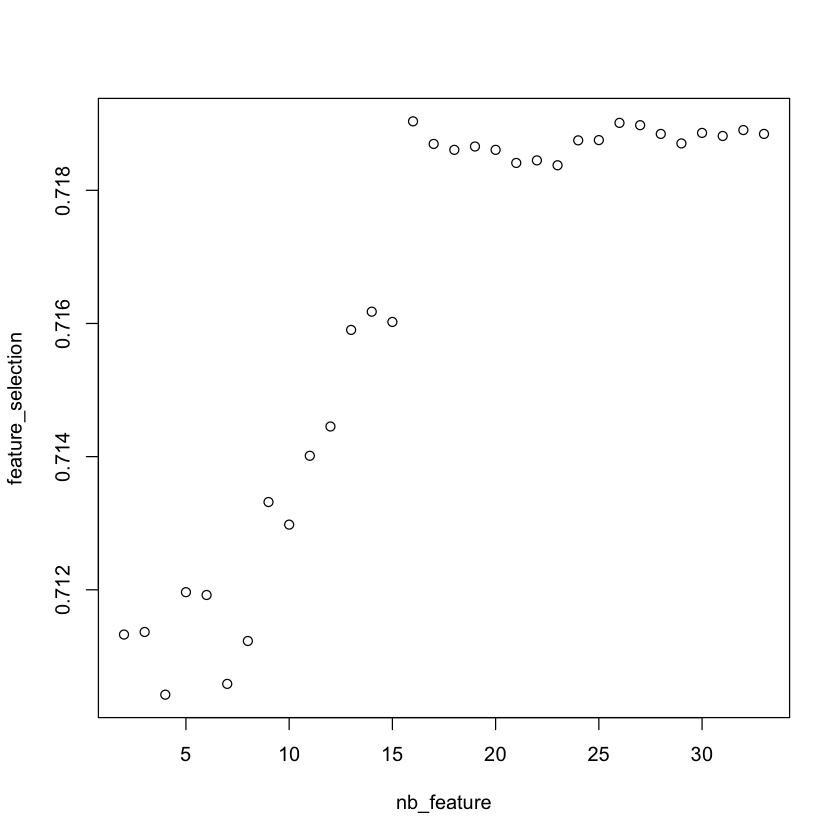

In [35]:
set.seed(2)

k = 10
accuracy_matrix <- matrix(0, nrow = (length(seq(2,length(rankingNN.lin),1))), ncol = k)

tic()
pb1 <- txtProgressBar(min = 1, max = (length(seq(2,length(rankingNN.lin),1))-1), style = 3)

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])


for (l in seq(2,length(rankingNN.lin),1)){
    X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
    y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

    X <- X[,rankingNN.lin[1:l]]
    
    Shuffle_idx <- sample(1:nrow(dataNN.lin))
    max <- ceiling(nrow(dataNN.lin)/k)
    splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
    pb2 <- txtProgressBar(min = 1, max = k, style = 3)
    tic()
    for (i in 1:k){
        X.test <- X[splits[[i]],]
        y.test <-  y[splits[[i]],]
        X.train <- X[-splits[[i]],]
        y.train <-  y[-splits[[i]],]
    
        X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

        beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
        pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

        cm <- matrix(0, nrow = 3, ncol = 3)
        for (j in 1:nrow(X.test)){
            cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1
        }
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_matrix[l-1,i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
    setTxtProgressBar(pb1, l-1)
    print(mean(accuracy_matrix[l-1,]))
    toc()
}

feature_selection <- accuracy_matrix %*% as.vector(rep(1/k,k))
nb_feature <- seq(2,length(rankingNN.lin),1)
plot(nb_feature,feature_selection)

On peux suprimer tous les feature apres 16 dans rankingNN.lin

In [37]:
set.seed(2)

k = 10
F_micro <- array(0,k)

Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN.lin[1:16]]

for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
    TP <- c(cm[1,1],cm[2,2],cm[3,3])
    FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
    FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
    P_micro <- sum(TP)/sum(TP+FP)
    R_micro <- sum(TP)/sum(TP+FN)
    F_micro[i] = (2*P_micro*R_micro)/(P_micro+R_micro)
}
print(mean(F_micro))

[1] 0.7190435


teston d'enlever les feature 4 dans rankingNN.lin

In [40]:
set.seed(2)
k = 10
accuracy_vec <- 1:k

X <- as.matrix(dataNN.lin[,setdiff(colnames(dataNN.lin),c("damage_grade_X1","damage_grade_X2","damage_grade_X3"))])
y <- as.matrix(dataNN.lin[,c("damage_grade_X1","damage_grade_X2","damage_grade_X3")])

X <- X[,rankingNN.lin[c(1,2,3,5,6,7,8,9,10,11,12,13,14,15,16)]]
Shuffle_idx <- sample(1:nrow(dataNN.lin))
max <- ceiling(nrow(dataNN.lin)/k)
splits <- split(Shuffle_idx, ceiling(seq_along(Shuffle_idx)/max))
pb2 <- txtProgressBar(min = 1, max = k, style = 3)
tic()
for (i in 1:k){
    X.test <- X[splits[[i]],]
    y.test <-  y[splits[[i]],]
    X.train <- X[-splits[[i]],]
    y.train <-  y[-splits[[i]],]
    
    X.train <- cbind(matrix(1, nr = nrow(X.train), nc = 1),X.train)

    beta_hat <- solve(t(X.train)%*%X.train)%*%t(X.train)%*%y.train
    
    pred <- cbind(matrix(1, nr = nrow(X.test), nc = 1),X.test) %*% beta_hat

    cm <- matrix(0, nrow = 3, ncol = 3)
    for (j in 1:nrow(X.test)){cm[which.max(pred[j,]),which.max(y.test[j,])] <- cm[which.max(pred[j,]),which.max(y.test[j,])]+1}
        TP <- c(cm[1,1],cm[2,2],cm[3,3])
        FP <- c(cm[2,1]+cm[3,1],cm[1,2]+cm[3,2],cm[1,3]+cm[2,3])
        FN <- c(cm[1,2]+cm[1,3],cm[2,1]+cm[2,3],cm[3,1]+cm[3,2])
        P_micro <- sum(TP)/sum(TP+FP)
        R_micro <- sum(TP)/sum(TP+FN)
        accuracy_vec[i] <- (2*P_micro*R_micro)/(P_micro+R_micro)
        
        setTxtProgressBar(pb2, i)
        print((2*P_micro*R_micro)/(P_micro+R_micro))
    }
print(mean(accuracy_vec))
toc()

  |                                                                      |   0%[1] 0.718656
  |========                                                              |  11%[1] 0.7220122
  |================                                                      |  22%[1] 0.7195818
  |=======================                                               |  33%[1] 0.7172672
  |===============================                                       |  44%[1] 0.7167657
  |=======================================                               |  56%[1] 0.713448
  |===============================================                       |  67%[1] 0.7183473
  |======================================================                |  78%[1] 0.720932
  |==============================================================        |  89%[1] 0.7195432
  |======================================================================| 100%[1] 0.7157411
[1] 0.7182295
2.211 sec elapsed


on remarque que cela baise le score f1 de notre model.

On vas donc s'areter là

### 2.2 Neural network

### 2.3 Random forest

### 2.4 Comparison of models 

# 3. Implementation of an other learning procedure

# 4. Submit our prediction to driven data 

# 5. Ranking of the features in terms of relevance

# 6. Conclusion 